### Imports

In [1]:
from collections import deque
import heapq
from itertools import combinations, chain
import networkx as nx
import matplotlib.pyplot as plt
from time import time
from collections import deque
import matplotlib

### Modelagem

#### Estado

In [2]:
class Estado:
    grupo_inicio : set
    tocha_inicio : bool
    def __init__(self, grupo_inicio : set, tocha_inicio : bool):
        self.grupo_inicio = grupo_inicio
        self.tocha_inicio = tocha_inicio

    # Necessário para printar a classe, e também necessário para fazer o typecast str() do Estado na hora de 'nomear' os vértices do grafo
    def __str__(self):
        self.grupo_inicio
        grupo_inicio_ordenado = ", ".join(str(p) for p in sorted(self.grupo_inicio))
        return f"{{{grupo_inicio_ordenado}}} {'inicio' if self.tocha_inicio else 'final'}"

    # Ajuda no print também
    def __repr__(self):
        return self.__str__()

    # Necessário para comparar as estruturas quando se roda os algoritmos, para questões de prioridade nas E.Ds e etc
    def __eq__(self, outro):
        return (self.grupo_inicio == outro.grupo_inicio and
                self.tocha_inicio == outro.tocha_inicio)

    # Permite usar Estado em sets e dicts
    def __hash__(self):
        return hash((frozenset(self.grupo_inicio), self.tocha_inicio))
    

#### Grafo

In [3]:
class Grafo:
    def __init__(self):
        # É um dicionário onde cada chave é um estado
        # e o valor é outro dicionário com {estado_vizinho: custo}
        self.lista_adjacencia = {}

    def adicionar_estado(self, estado : Estado):
        rotulo_vertice = str(estado)

        if rotulo_vertice not in self.lista_adjacencia:
            self.lista_adjacencia[rotulo_vertice] = {}
    
    def adicionar_aresta(self, estado1 : Estado, estado2 : Estado, custo : int):
        rotulo_vertice1 = str(estado1)
        rotulo_vertice2 = str(estado2)
            
        for rotulo in [rotulo_vertice1, rotulo_vertice2]:
            if rotulo not in self.lista_adjacencia:
                self.adicionar_estado(rotulo)
        self.lista_adjacencia[rotulo_vertice1][rotulo_vertice2] = custo

    def show(self, titulo="Algoritmo", descricao=""):
        G = nx.DiGraph()
        for v1, vizinhos in self.lista_adjacencia.items():
            for v2, custo in vizinhos.items():
                G.add_edge(v1, v2, weight=custo)

        plt.figure(figsize=(15, 10))
        pos = nx.spring_layout(G, seed=40,k=1)
        nx.draw(G, pos, with_labels=True, node_size=2000, node_color="lightblue", font_size=12)
        labels = nx.get_edge_attributes(G, 'weight')
        nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)
        plt.title(titulo, fontsize=20)
        plt.text(-0.2, 0.5, descricao, fontsize=14, ha='left', va='center', transform=plt.gca().transAxes)
        plt.show(block=True)

#### Passo

In [4]:
class Passo:
    def __init__(self, estado_origem, estado_destino, grupo_viajante, custo):
        self.estado_origem = estado_origem
        self.estado_destino = estado_destino
        self.grupo_viajante = grupo_viajante
        self.custo = custo

    def __str__(self):
        grupo_passageiros = ", ".join(str(p) for p in sorted(self.grupo_viajante))
        return f"Estado destino: {self.estado_destino}; Passageiros: {{{grupo_passageiros}}}; Custo: {self.custo}"

    def __repr__(self):
        return f"Passo({self.estado_origem} -> {self.estado_destino}, {self.grupo_viajante}, {self.custo})"


### Parâmetros do Problema

In [5]:
# Tempos das pessoas
TEMPOS = {'A': 1, 'B': 2, 'C': 5, 'D': 10}

# Todas as pessoas
PESSOAS = set(TEMPOS.keys())
print(f"Dicionário de tempos: {TEMPOS}, Conjunto de pessoas: {PESSOAS}")

estado_inicial = Estado(grupo_inicio=PESSOAS, tocha_inicio=True)
estado_final = Estado(grupo_inicio=set(), tocha_inicio=False)
print(f"estado inicial: {estado_inicial}")
print(f"estado final: {estado_final}")

Dicionário de tempos: {'A': 1, 'B': 2, 'C': 5, 'D': 10}, Conjunto de pessoas: {'D', 'A', 'B', 'C'}
estado inicial: {A, B, C, D} inicio
estado final: {} final


#### Função Sucessora

In [6]:
# Gera todos os grupos possíveis de viajantes
# Usado para definir quem pode atravessar a ponte em um passo
# Exemplo: se grupo_pessoas = {"A", "B", "C"}, retorna:
# {"A"}, {"B"}, {"C"}, {"A","B"}, {"A","C"}, {"B","C"}
def gerar_grupos_viajantes(grupo_pessoas: set):
    casos_pessoa_isolada = (set(combination) for combination in combinations(grupo_pessoas, 1))
    casos_dupla = (set(combination) for combination in combinations(grupo_pessoas, 2))
    return chain(casos_pessoa_isolada, casos_dupla)

print("possíveis grupos viajantes para o estado inicial: ")
for grupo_viajante in gerar_grupos_viajantes(PESSOAS):
    print(grupo_viajante, end=' ')

possíveis grupos viajantes para o estado inicial: 
{'D'} {'A'} {'B'} {'C'} {'A', 'D'} {'D', 'B'} {'D', 'C'} {'A', 'B'} {'A', 'C'} {'B', 'C'} 

In [7]:
def funcao_sucessora(estado : Estado) -> list[Passo]:
    possiveis_passos = []

    if estado.tocha_inicio:
        for grupo_viajante in gerar_grupos_viajantes(estado.grupo_inicio):
            novo_grupo_inicio = estado.grupo_inicio - grupo_viajante
            estado_sucessor = Estado(grupo_inicio=novo_grupo_inicio, tocha_inicio=False)
            custo = max(map(TEMPOS.get, grupo_viajante))
            possiveis_passos.append(Passo(estado_origem=estado, estado_destino=estado_sucessor, grupo_viajante=grupo_viajante, custo=custo))
    else:
        grupo_fim = PESSOAS - estado.grupo_inicio
        for grupo_viajante in gerar_grupos_viajantes(grupo_fim):
            novo_grupo_inicio = estado.grupo_inicio | grupo_viajante
            estado_sucessor = Estado(grupo_inicio=novo_grupo_inicio, tocha_inicio=True)
            custo = max(map(TEMPOS.get, grupo_viajante))
            possiveis_passos.append(Passo(estado_origem=estado, estado_destino=estado_sucessor, grupo_viajante=grupo_viajante, custo=custo))

    return possiveis_passos

print("Sucessores do estado inicial:")
for passo in funcao_sucessora(estado_inicial):
    print(passo)

Sucessores do estado inicial:
Estado destino: {A, B, C} final; Passageiros: {D}; Custo: 10
Estado destino: {B, C, D} final; Passageiros: {A}; Custo: 1
Estado destino: {A, C, D} final; Passageiros: {B}; Custo: 2
Estado destino: {A, B, D} final; Passageiros: {C}; Custo: 5
Estado destino: {B, C} final; Passageiros: {A, D}; Custo: 10
Estado destino: {A, C} final; Passageiros: {B, D}; Custo: 10
Estado destino: {A, B} final; Passageiros: {C, D}; Custo: 10
Estado destino: {C, D} final; Passageiros: {A, B}; Custo: 2
Estado destino: {B, D} final; Passageiros: {A, C}; Custo: 5
Estado destino: {A, D} final; Passageiros: {B, C}; Custo: 5


## Funções auxiliares para plotar as soluções

In [8]:
def print_caminho(caminho, estado_inicial, custo_total, tempo, nos_expandidos):
    estado_atual = estado_inicial
    print(f"{0}: Estado inicial: {estado_atual}")
    for i, passo in enumerate(caminho):
        print(f"{i+1}: Passo: {passo.grupo_viajante} levam a tocha para o {'inicio' if passo.estado_destino.tocha_inicio else 'final'} (custo: {passo.custo})")
        estado_atual = passo.estado_destino
    print(f"Estado final: {estado_atual}")
    print(f"Custo total: {custo_total}, Tempo: {tempo:.6f}s, Nós expandidos: {nos_expandidos}")

def plot_metricas(resultados_algoritmos,colormap):
    algoritmos = list(resultados_algoritmos.keys())
    custo_total = [resultados_algoritmos[a][1] for a in algoritmos]
    tempo = [resultados_algoritmos[a][2] for a in algoritmos]
    nos_expandidos = [resultados_algoritmos[a][3] for a in algoritmos]

    colormap = matplotlib.colormaps[colormap]
    bar_colors = [colormap(i / len(algoritmos)) for i in range(len(algoritmos))]
    

    fig, axs = plt.subplots(1, 3, figsize=(18, 5))

    axs[0].barh(algoritmos, custo_total, color=bar_colors)
    axs[0].set_title("Custo Total")
    axs[0].set_xlabel("Custo")

    axs[1].barh(algoritmos, tempo, color=bar_colors)
    axs[1].set_title("Tempo (s)")
    axs[1].set_xlabel("Segundos")

    axs[2].barh(algoritmos, nos_expandidos, color=bar_colors)
    axs[2].set_title("Nós Expandidos")
    axs[2].set_xlabel("Contagem")

    plt.tight_layout()
    plt.show()


def caminho_para_grafo(estado_inicial: Estado, caminho: list, nome_algoritmo: str = "algoritmo", descricao : str = ""):
    g = Grafo()

    for passo in caminho:
        g.adicionar_aresta(passo.estado_origem, passo.estado_destino, passo.custo)

    g.show(titulo=nome_algoritmo,descricao=descricao)

resultados_algoritmos = {}



### Métodos de busca não informada

#### Busca em largura (BFS)

In [9]:
def bfs(estado_inicial : Estado, estado_objetivo : Estado):
    inicio = time()
    
    visitados = set()
    visitados.add(estado_inicial)
    
    fila = deque()
    fila.append((estado_inicial, [], 0))
    
    nos_expandidos = 0
    
    while fila:
        estado_atual, caminho, custo_atual = fila.popleft()
        nos_expandidos += 1
        
        for passo in funcao_sucessora(estado_atual):
            # se o sucessor é o estado final, terminamos
            if passo.estado_destino.grupo_inicio == estado_objetivo.grupo_inicio:
                fim = time()
                caminho_completo = caminho + [passo]
                return caminho_completo, custo_atual + passo.custo, fim - inicio, nos_expandidos

            if passo.estado_destino not in visitados:
                visitados.add(passo.estado_destino)
                novo_caminho = caminho + [passo]
                fila.append((passo.estado_destino, novo_caminho, custo_atual + passo.custo))
    
    fim = time()
    return None, None, fim - inicio, nos_expandidos

0: Estado inicial: {A, B, C, D} inicio
1: Passo: {'A', 'D'} levam a tocha para o final (custo: 10)
2: Passo: {'A'} levam a tocha para o inicio (custo: 1)
3: Passo: {'A', 'B'} levam a tocha para o final (custo: 2)
4: Passo: {'A'} levam a tocha para o inicio (custo: 1)
5: Passo: {'A', 'C'} levam a tocha para o final (custo: 5)
Estado final: {} final
Custo total: 19, Tempo: 0.000000s, Nós expandidos: 20


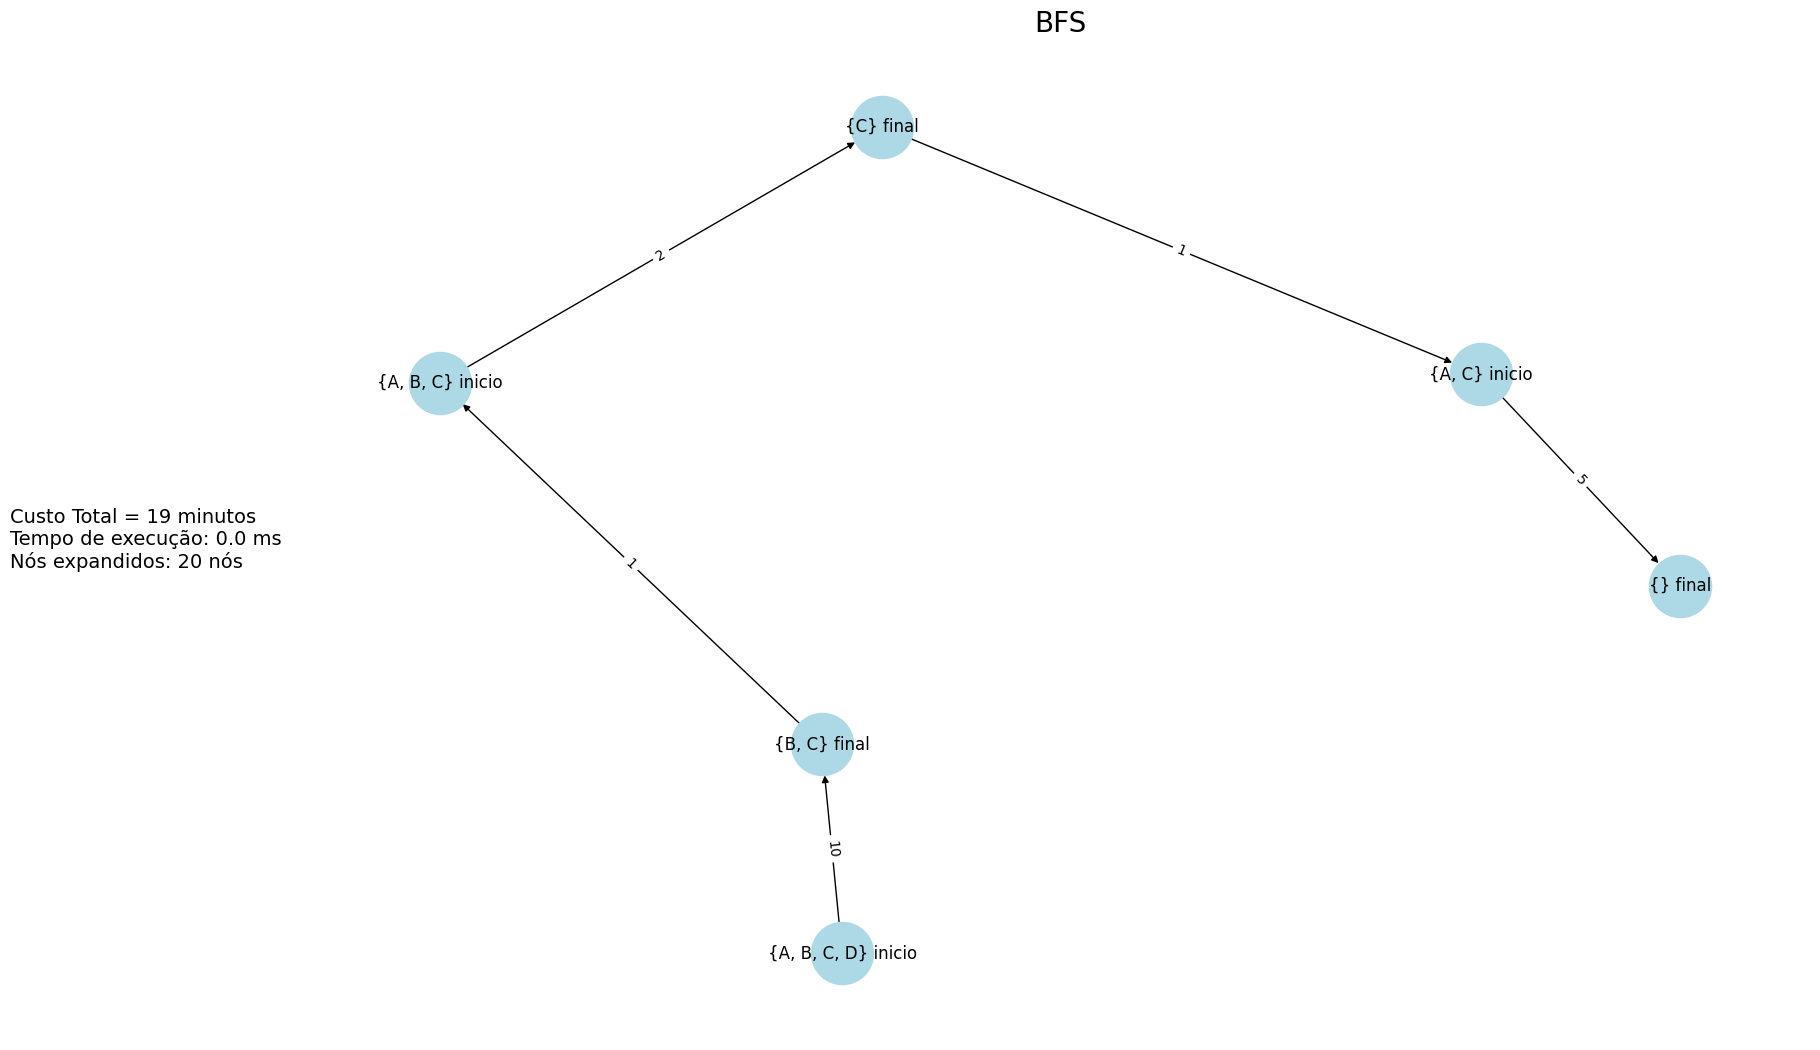

In [10]:
resultados_algoritmos["BFS"] = bfs(estado_inicial, estado_final)
caminho, custo_total, tempo, nos_expandidos = resultados_algoritmos["BFS"]
descricao = f"Custo Total = {custo_total} minutos\nTempo de execução: {round((tempo*1000),4)} ms\nNós expandidos: {nos_expandidos} nós"
print_caminho(caminho, estado_inicial, custo_total, tempo, nos_expandidos)
caminho_para_grafo(estado_inicial, caminho, "BFS", descricao)

#### Busca em profundidade (DFS)

In [11]:
def dfs(estado_inicial: Estado, estado_objetivo: Estado, limite=10_000):
    inicio = time()
    
    visitados = set()
    pilha = [(estado_inicial, [], 0)]
    
    nos_expandidos = 0
    
    while pilha and nos_expandidos < limite:
        estado_atual, caminho, custo_atual = pilha.pop()
        
        if estado_atual in visitados:
            continue
        visitados.add(estado_atual)

        nos_expandidos += 1
        
        if estado_atual == estado_objetivo:
            fim = time()
            return caminho, custo_atual, fim - inicio, nos_expandidos

        for passo in funcao_sucessora(estado_atual):
            novo_caminho = caminho + [passo]
            pilha.append((passo.estado_destino, novo_caminho, custo_atual + passo.custo))
    
    fim = time()
    return None, None, fim - inicio, nos_expandidos


0: Estado inicial: {A, B, C, D} inicio
1: Passo: {'B', 'C'} levam a tocha para o final (custo: 5)
2: Passo: {'C'} levam a tocha para o inicio (custo: 5)
3: Passo: {'D', 'C'} levam a tocha para o final (custo: 10)
4: Passo: {'B', 'C'} levam a tocha para o inicio (custo: 5)
5: Passo: {'A', 'C'} levam a tocha para o final (custo: 5)
6: Passo: {'D', 'C'} levam a tocha para o inicio (custo: 10)
7: Passo: {'B', 'C'} levam a tocha para o final (custo: 5)
8: Passo: {'C'} levam a tocha para o inicio (custo: 5)
9: Passo: {'D', 'C'} levam a tocha para o final (custo: 10)
Estado final: {} final
Custo total: 60, Tempo: 0.000000s, Nós expandidos: 13


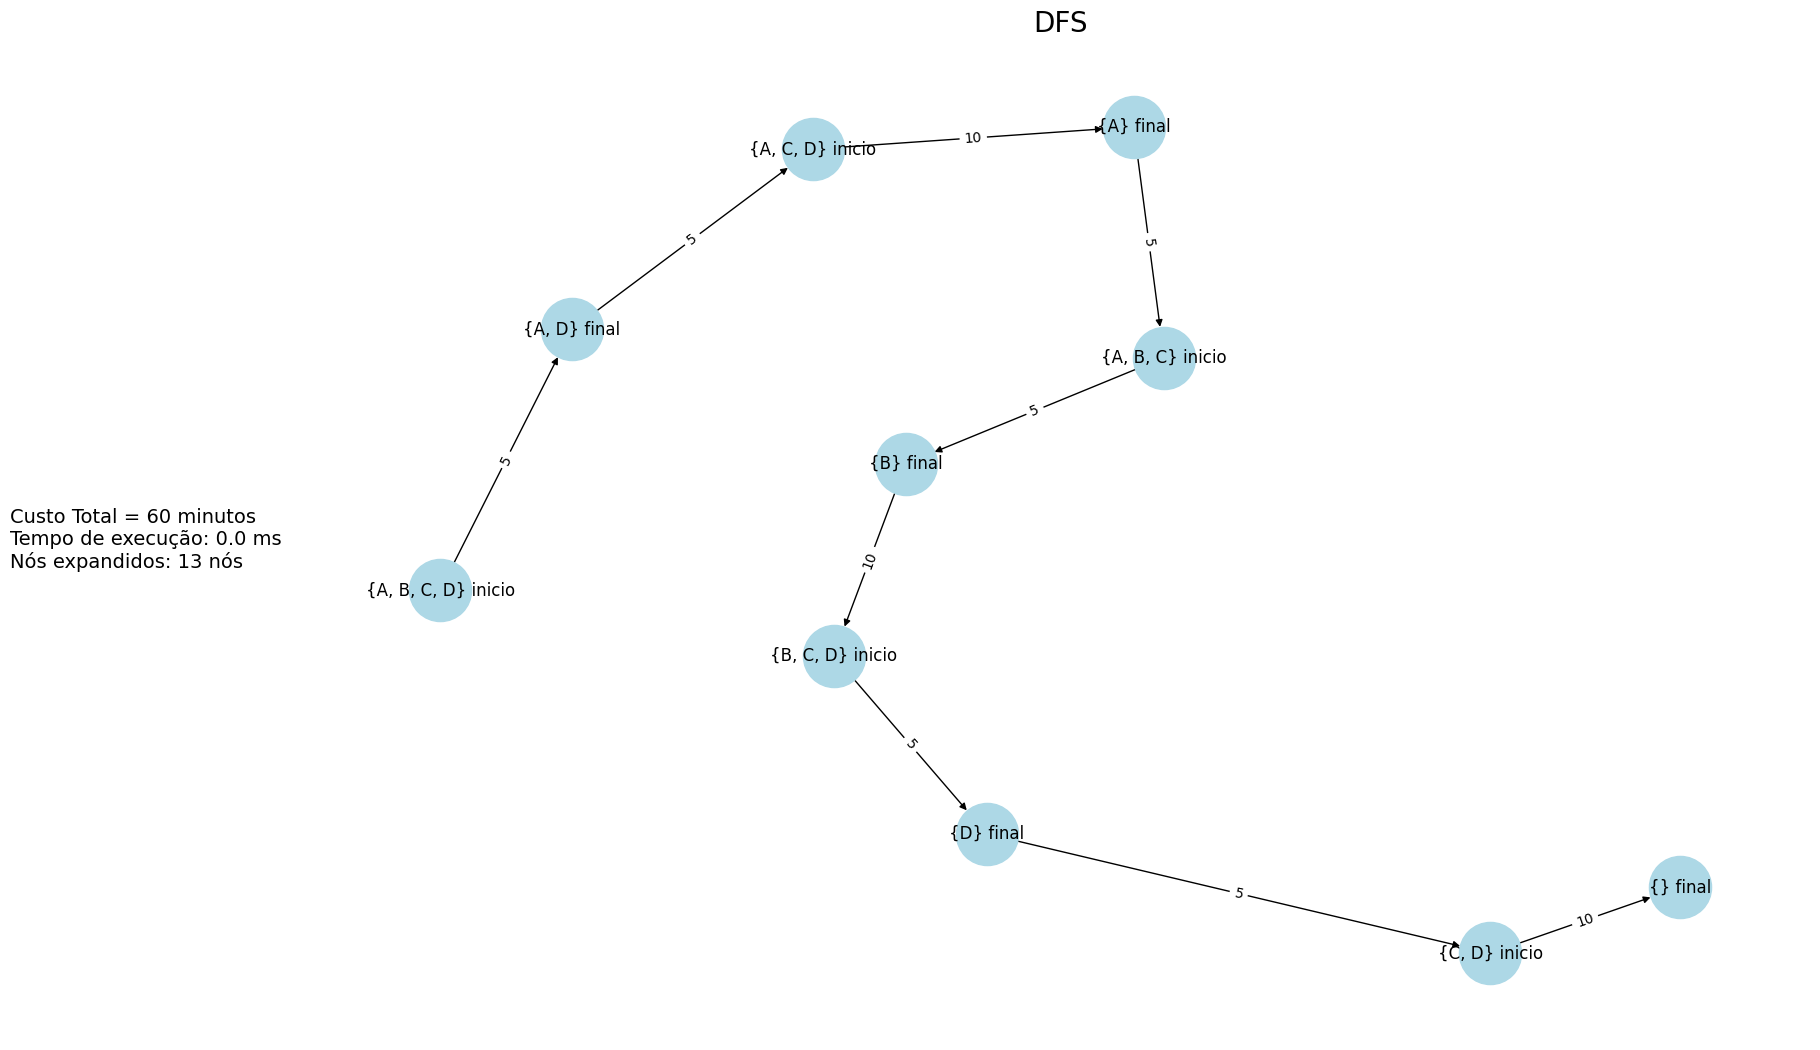

In [12]:
resultados_algoritmos["DFS"] = dfs(estado_inicial, estado_final)
caminho, custo_total, tempo, nos_expandidos = resultados_algoritmos["DFS"]
descricao = f"Custo Total = {custo_total} minutos\nTempo de execução: {round((tempo*1000),4)} ms\nNós expandidos: {nos_expandidos} nós"
print_caminho(caminho, estado_inicial, custo_total, tempo, nos_expandidos)
caminho_para_grafo(estado_inicial, caminho, "DFS", descricao)

### Métodos de busca informada

#### Custo Uniforme

In [13]:
def custo_uniforme(estado_inicial: Estado, estado_objetivo: Estado):
    inicio = time()
    
    # armazena o menor custo conhecido até cada estado
    melhor_custo = {estado_inicial: 0}  
    heap = []
    contador = 0 
    heapq.heappush(heap, (0, contador, estado_inicial, []))
    
    nos_expandidos = 0
    
    while heap:
        custo_atual, _, estado_atual, caminho = heapq.heappop(heap)
        nos_expandidos += 1

        # ignora caminhos piores do que o melhor já conhecido
        if custo_atual > melhor_custo.get(estado_atual, float('inf')):
            continue

        # se o estado atual é o objetivo, terminamos
        if estado_atual == estado_objetivo:
            fim = time()
            return caminho, custo_atual, fim - inicio, nos_expandidos
        
        # gera sucessores
        for passo in funcao_sucessora(estado_atual):
            estado_sucessor = passo.estado_destino
            novo_custo = custo_atual + passo.custo

            # só processa se encontrou um caminho mais barato
            if novo_custo < melhor_custo.get(estado_sucessor, float('inf')):
                melhor_custo[estado_sucessor] = novo_custo
                novo_caminho = caminho + [passo]
                contador += 1
                heapq.heappush(heap, (novo_custo, contador, estado_sucessor, novo_caminho))
    
    fim = time()
    return None, None, fim - inicio, nos_expandidos


0: Estado inicial: {A, B, C, D} inicio
1: Passo: {'A', 'B'} levam a tocha para o final (custo: 2)
2: Passo: {'A'} levam a tocha para o inicio (custo: 1)
3: Passo: {'D', 'C'} levam a tocha para o final (custo: 10)
4: Passo: {'B'} levam a tocha para o inicio (custo: 2)
5: Passo: {'A', 'B'} levam a tocha para o final (custo: 2)
Estado final: {} final
Custo total: 17, Tempo: 0.000000s, Nós expandidos: 26


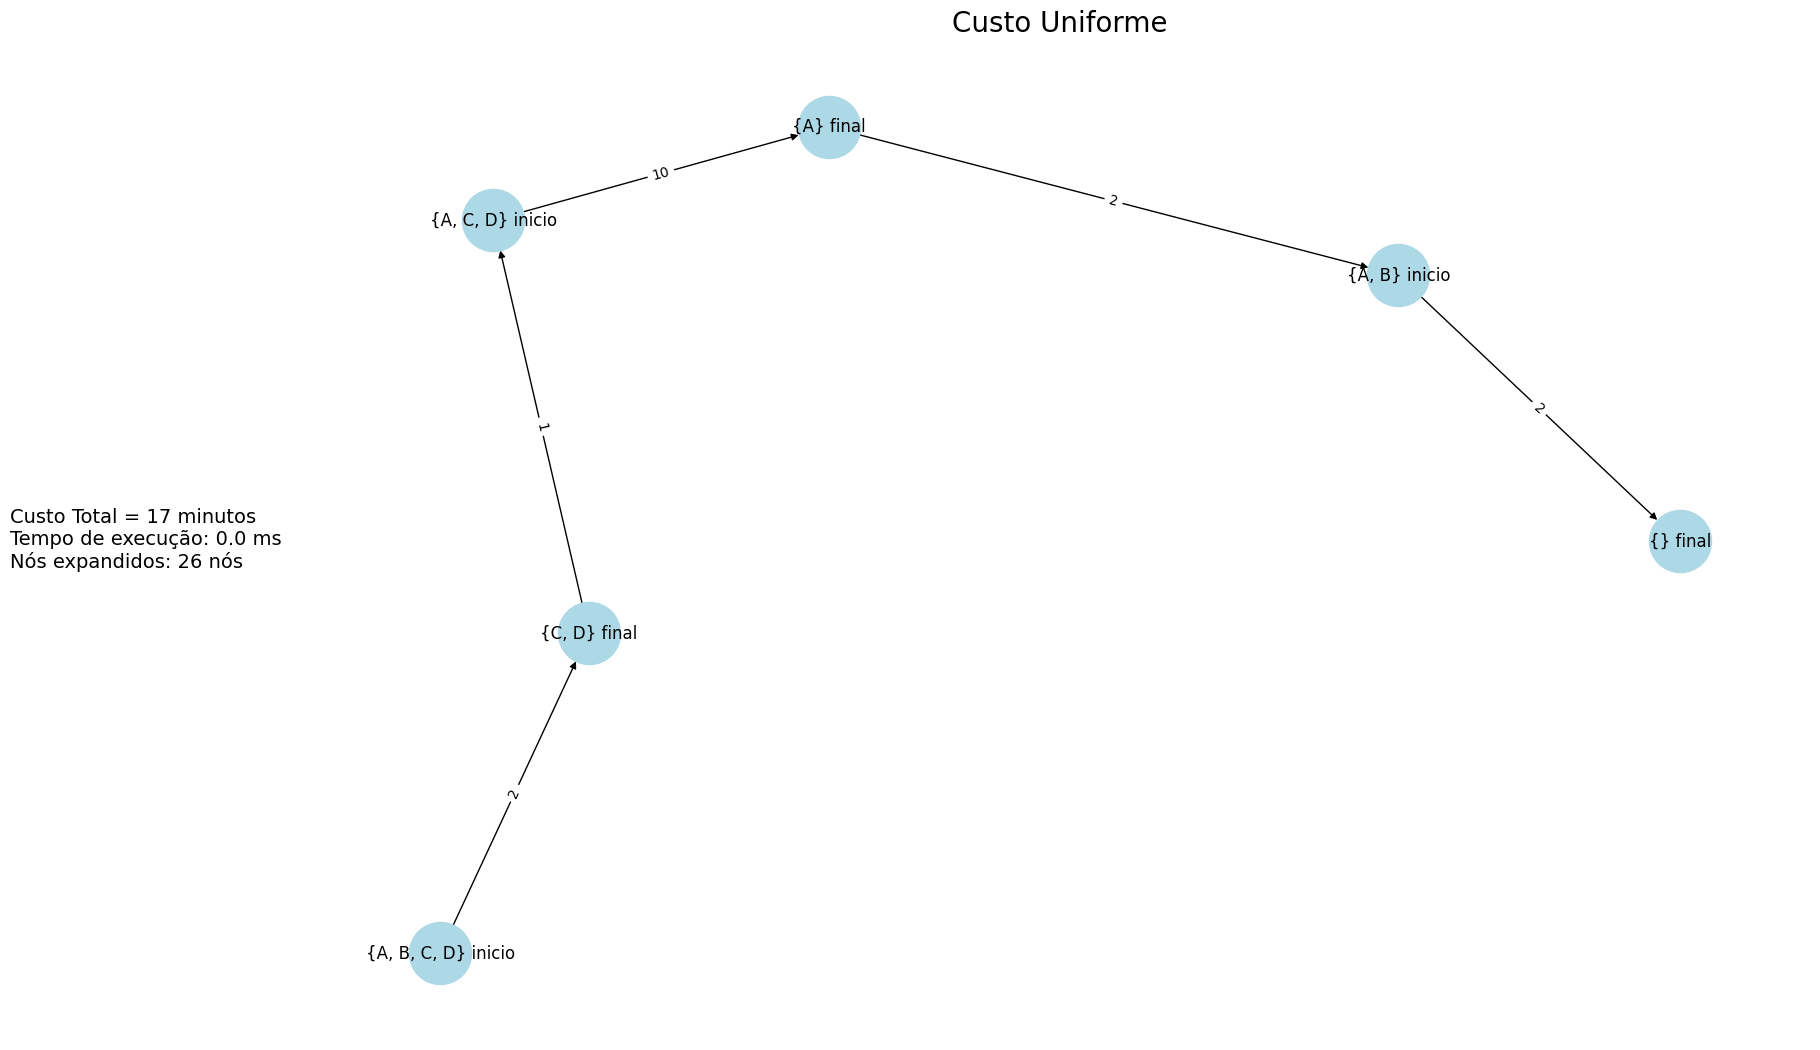

In [14]:
resultados_algoritmos["Custo Uniforme"] = custo_uniforme(estado_inicial, estado_final)
caminho, custo_total, tempo, nos_expandidos = resultados_algoritmos["Custo Uniforme"]
descricao = f"Custo Total = {custo_total} minutos\nTempo de execução: {round((tempo*1000),4)} ms\nNós expandidos: {nos_expandidos} nós"
print_caminho(caminho, estado_inicial, custo_total, tempo, nos_expandidos)
caminho_para_grafo(estado_inicial,caminho,"Custo Uniforme",descricao)

#### A-estrela

In [15]:
# Heurística: soma dos tempos de todos que ainda estão no lado inicial dividida por 2
def heuristica_soma_div2(estado: Estado):
    lado_inicio = estado.grupo_inicio
    if not lado_inicio:
        return 0
    return sum(TEMPOS[p] for p in lado_inicio) / 2

# Heurística: tempo da pessoa mais lenta que ainda não atravessou
def heuristica_maior_tempo_restante(estado: Estado):
    lado_inicio = estado.grupo_inicio
    if not lado_inicio:
        return 0
    return max(TEMPOS[p] for p in lado_inicio)

def a_estrela(estado_inicial: Estado, estado_objetivo: Estado, funcao_heuristica):
    inicio = time()

    # armazena o menor custo conhecido para cada estado
    melhor_custo = {estado_inicial: 0} 
    heap = []
    contador = 0
    f0 = funcao_heuristica(estado_inicial)
    heapq.heappush(heap, (f0, contador, 0, estado_inicial, []))
    
    nos_expandidos = 0

    while heap:
        f_atual, _, g_atual, estado_atual, caminho = heapq.heappop(heap)
        nos_expandidos += 1

        # Se chegamos ao estado objetivo, retornamos o resultado
        if estado_atual == estado_objetivo:
            fim = time()
            return caminho, g_atual, fim - inicio, nos_expandidos

        # Ignora caminhos piores que o melhor já conhecido
        if g_atual > melhor_custo.get(estado_atual, float('inf')):
            continue

        # Gera sucessores
        for passo in funcao_sucessora(estado_atual):
            estado_sucessor = passo.estado_destino
            g_novo = g_atual + passo.custo
            f_novo = g_novo + funcao_heuristica(estado_sucessor)

            # Se encontramos um caminho melhor para esse estado, atualiza
            if g_novo < melhor_custo.get(estado_sucessor, float('inf')):
                melhor_custo[estado_sucessor] = g_novo
                novo_caminho = caminho + [passo]
                contador += 1
                heapq.heappush(heap, (f_novo, contador, g_novo, estado_sucessor, novo_caminho))
    
    fim = time()
    return None, None, fim - inicio, nos_expandidos


0: Estado inicial: {A, B, C, D} inicio
1: Passo: {'A', 'B'} levam a tocha para o final (custo: 2)
2: Passo: {'A'} levam a tocha para o inicio (custo: 1)
3: Passo: {'D', 'C'} levam a tocha para o final (custo: 10)
4: Passo: {'B'} levam a tocha para o inicio (custo: 2)
5: Passo: {'A', 'B'} levam a tocha para o final (custo: 2)
Estado final: {} final
Custo total: 17, Tempo: 0.000000s, Nós expandidos: 19


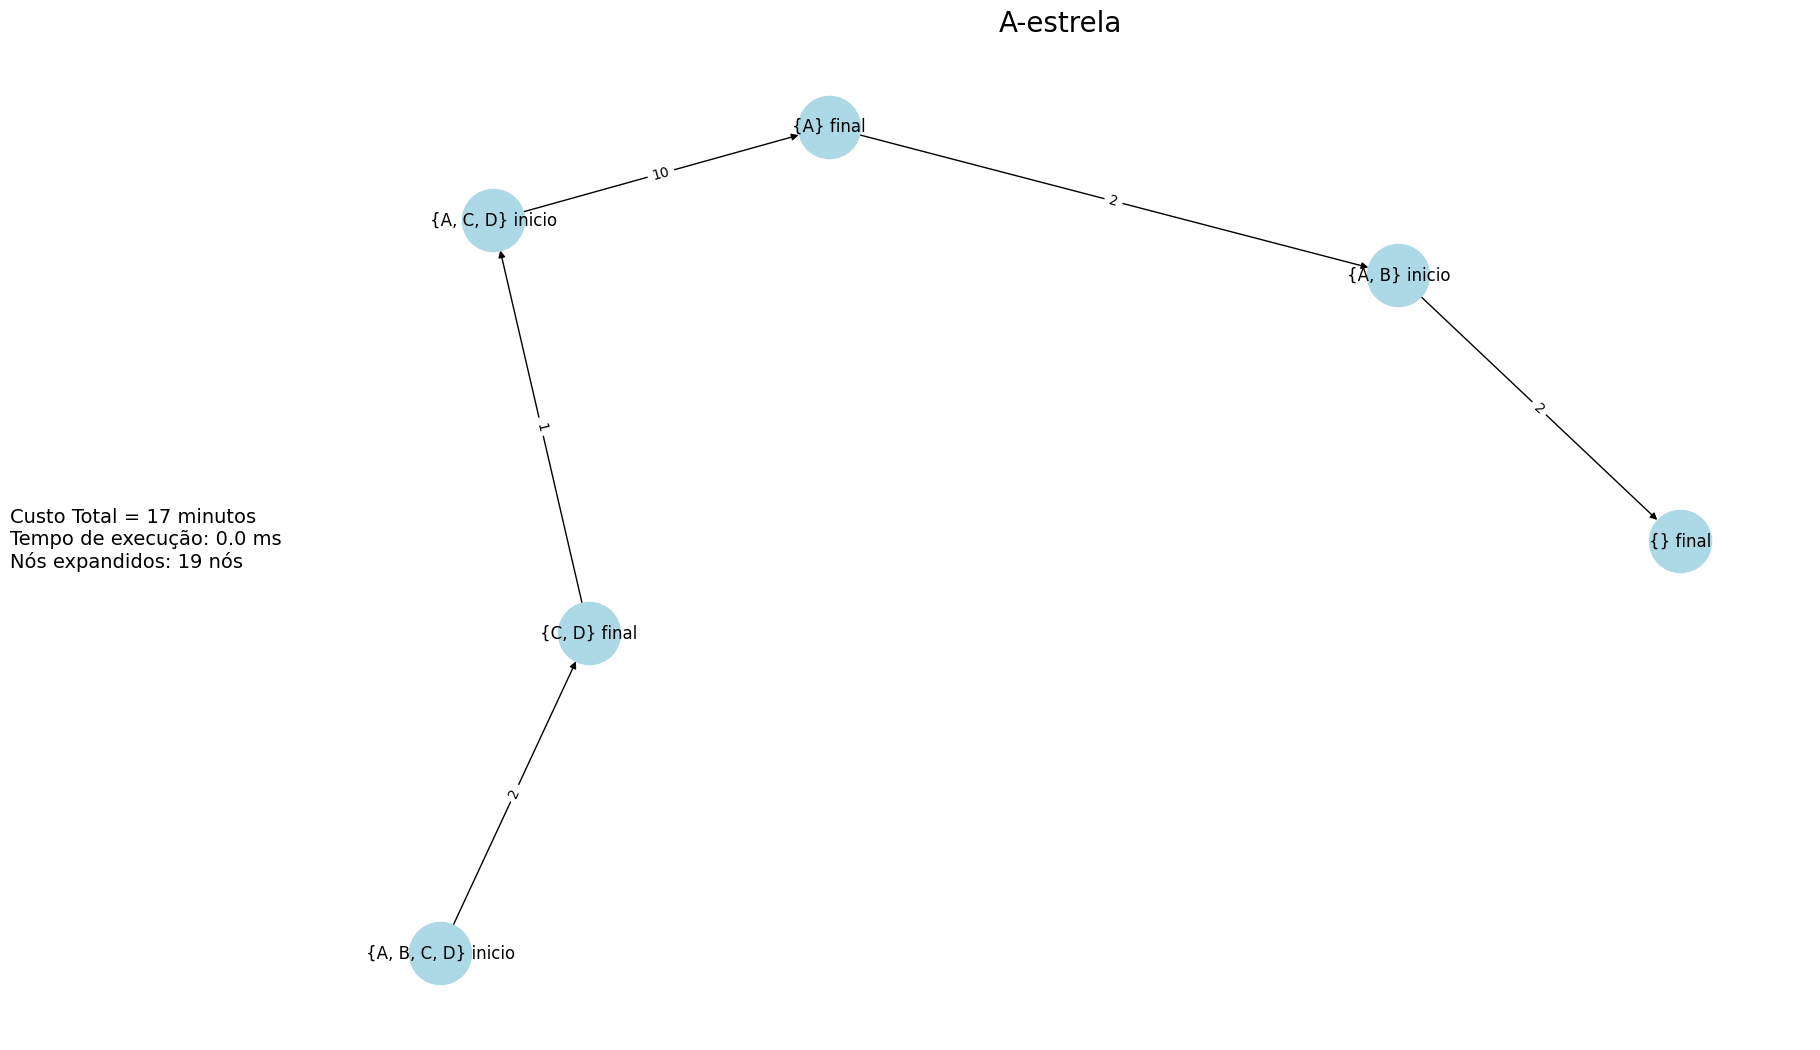

In [19]:
resultados_algoritmos["A-estrela"] = a_estrela(estado_inicial, estado_final, heuristica_maior_tempo_restante)
caminho, custo_total, tempo, nos_expandidos = resultados_algoritmos["A-estrela"]
descricao = f"Custo Total = {custo_total} minutos\nTempo de execução: {round((tempo*1000),4)} ms\nNós expandidos: {nos_expandidos} nós"
print_caminho(caminho, estado_inicial, custo_total, tempo, nos_expandidos)
caminho_para_grafo(estado_inicial, caminho, "A-estrela", descricao)

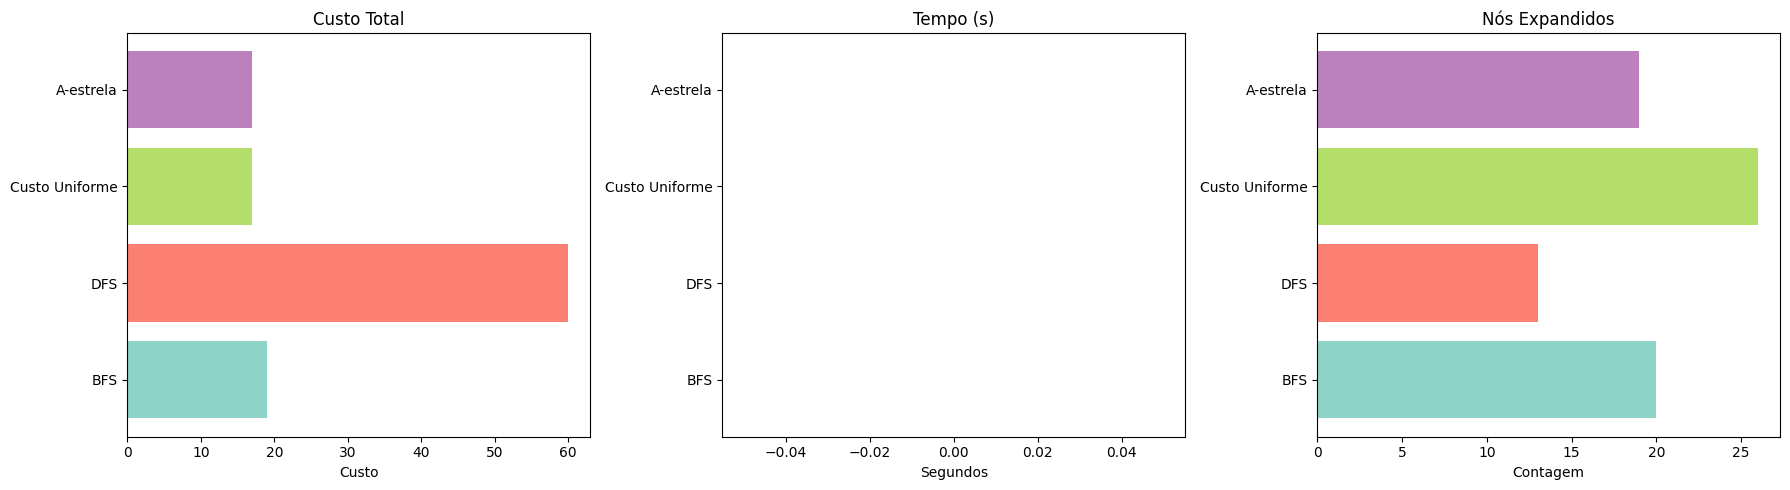

In [20]:
plot_metricas(resultados_algoritmos,"Set3")